## 7.15 대칭성 적응 양자 회로를 이용한 양자 화학 시뮬레이션

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit.visualization import plot_histogram
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 대칭성 적응 해밀토니안 정의
h_pauli_terms = {
    "II": -1.052373245772859,
    "IZ": 0.39793742484318045,
    "ZI": -0.39793742484318045,
    "ZZ": -0.01128010425623538,
    "XX": 0.18093119978423156,
}

In [3]:
# 해밀토니안을 SparsePauliOp로 생성
pauli_op_list = [(pauli_str, coef) for pauli_str, coef in h_pauli_terms.items()]
hamiltonian = SparsePauliOp.from_list(pauli_op_list)

In [4]:
# 대칭성 적응 양자회로 정의 (2큐비트 계)
def create_symmetry_adapted_circuit(num_qubits, params):
    qc = QuantumCircuit(num_qubits)

    # 대칭성 적응 초기 상태
    qc.h(0)
    qc.cx(0, 1)

    # 매개변수 게이트 적용
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    # 얽힘 게이트
    qc.cx(0, 1)

    return qc

In [5]:
# 회로 매개변수 정의
params = np.random.random(2)

In [6]:
# 대칭성 적응 양자회로 생성
symmetry_circuit = create_symmetry_adapted_circuit(2, params)

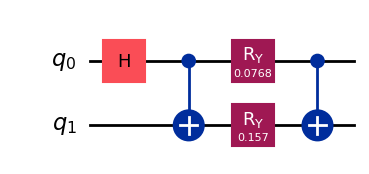

In [7]:
# 대칭성 적응 양자회로 시각화
symmetry_circuit.draw('mpl')
plt.show()

In [8]:
# 전자구조 문제용 VQE (상태벡터를 위해 측정 없이)
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기
ansatz = EfficientSU2(num_qubits=2, entanglement='linear')  # 앤사츠 회로 정의

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_6/1791582885.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=2, entanglement='linear')  # 앤사츠 회로 정의


In [9]:
# 최대 반복 횟수를 갖는 최적화기 정의
optimizer = COBYLA(maxiter=100)

In [10]:
# AerSimulator로 VQE 실행
simulator = AerSimulator()  # AerSimulator 사용

In [11]:
symmetry_circuit = transpile(symmetry_circuit, simulator)  # 시뮬레이터용 트랜스파일

In [12]:
# 측정이 있는 회로의 별도 실행
measured_circuit = create_symmetry_adapted_circuit(2, params)
measured_circuit.measure_all()  # 모든 큐비트에 측정 추가

In [13]:
# 측정이 있는 회로 실행 (별도 실행)
measured_job = simulator.run(measured_circuit)
measured_result = measured_job.result()

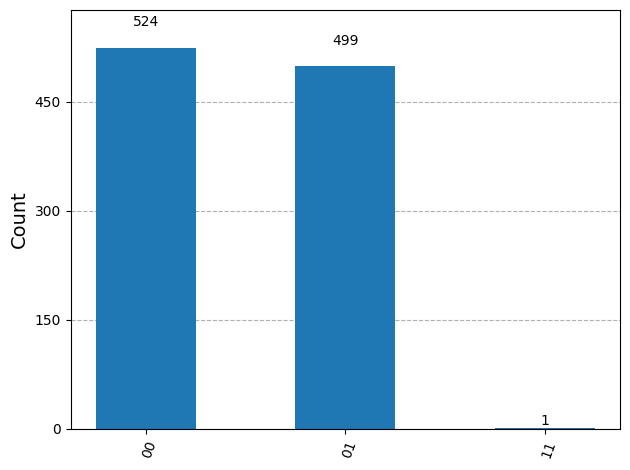

In [14]:
# 카운트 획득 및 시각화 (히스토그램)
counts = measured_result.get_counts()
plot_histogram(counts)
plt.show()